<a href="https://colab.research.google.com/github/danielmogo25/Proyecto-UNAL-ChatMP3/blob/main/Chat_mp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importamos las librerias que vamos a usar
import requests
import sqlite3
from IPython.display import Audio
from IPython.display import Image, display
import pandas as pd


In [ ]:
def obtener_o_crear_id(cur, tabla, nombre):
    """
    Inserta 'nombre' en 'tabla' si no existe, y devuelve su id.
    Sirve para Artista, Album y Genero (todas tienen la misma estructura: id, nombre).
    """
    cur.execute(f"INSERT OR IGNORE INTO {tabla} (nombre) VALUES (?)", (nombre,))
    cur.execute(f"SELECT id FROM {tabla} WHERE nombre = ?", (nombre,))
    return cur.fetchone()[0]

In [ ]:
def insertar_cancion(cur, dato):
    titulo = dato.get('trackName')
    nombre_artista = dato.get('artistName')
    nombre_album = dato.get('collectionName')
    nombre_genero = dato.get('primaryGenreName')
    preview = dato.get('previewUrl')
    milisegundos = dato.get('trackTimeMillis') or 0
    fecha_raw = dato.get('releaseDate')
    fecha = int(fecha_raw[:4]) if fecha_raw else None

    # 1. Resolver artista, album y genero a sus ids
    artista_id = obtener_o_crear_id(cur, "Artista", nombre_artista)
    album_id = obtener_o_crear_id(cur, "Album", nombre_album)
    genero_id = obtener_o_crear_id(cur, "Genero", nombre_genero)

    # 2. Insertar la cancion usando esos ids
    cur.execute('''
        INSERT OR IGNORE INTO Track (titulo, artista_id, album_id, duracion, fecha, preview)
        VALUES (?, ?, ?, ?, ?, ?)
    ''', (titulo, artista_id, album_id, milisegundos, fecha, preview))

In [ ]:
cur.execute('''
    SELECT Track.titulo, Artista.nombre, Album.nombre, Genero.nombre, Track.duracion
    FROM Track
    JOIN Artista ON Track.artista_id = Artista.id
    JOIN Album ON Track.album_id = Album.id
    JOIN Genero ON Track.genero_id = Genero.id
''')

for fila in cur.fetchall():
    print(fila)

In [ ]:

#Creacion base de datos
conn = sqlite3.connect('base_datos_chat_mp3.sqlite')
cur=conn.cursor()
cur.executescript('''
DROP TABLE IF EXISTS Track;
DROP TABLE IF EXISTS Artista;
DROP TABLE IF EXISTS Genero;
DROP TABLE IF EXISTS Album;

CREATE TABLE Track(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
titulo TEXT UNIQUE,
artista_id,
album_id INTEGER,
duracion INTEGER,
fecha INTEGER,
preview INTEGER
);
CREATE TABLE Artista(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
nombre TEXT UNIQUE
);
CREATE TABLE Album(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
nombre TEXT UNIQUE
);
CREATE TABLE Genero(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
nombre TEXT UNIQUE
)
''')
conn.commit()


In [ ]:
def descargar_imagen(url,nombre_archivo):
  """
    Descarga un archivo binario desde una URL y lo guarda en disco.

    Args:
        url (str): URL del archivo a descargar.
        nombre_archivo (str): nombre con el que se guardará localmente.

    Returns:
        bool: True si la descarga fue exitosa, False si falló.
    """

  try:
      respuesta = requests.get(url, stream=True, timeout=10)
      respuesta.raise_for_status()

      with open(nombre_archivo, "wb") as archivo:
          for bloque in respuesta.iter_content(chunk_size=8192):
              archivo.write(bloque)

      print(f" Archivo guardado como '{nombre_archivo}'")
      return True

  except requests.exceptions.Timeout:
      print(" La descarga tardó demasiado y se canceló.")
  except requests.exceptions.RequestException as error:
      print(f" No se pudo descargar el archivo: {error}")

  return False

ESTADO RESPUESTA 200

DATOS JSON [{'wrapperType': 'track', 'kind': 'song', 'artistId': 32940, 'collectionId': 186166282, 'trackId': 186166433, 'artistName': 'Michael Jackson', 'collectionName': 'Off the Wall', 'trackName': 'Off the Wall', 'collectionCensoredName': 'Off the Wall', 'trackCensoredName': 'Off the Wall', 'artistViewUrl': 'https://music.apple.com/us/artist/michael-jackson/32940?uo=4', 'collectionViewUrl': 'https://music.apple.com/us/album/off-the-wall/186166282?i=186166433&uo=4', 'trackViewUrl': 'https://music.apple.com/us/album/off-the-wall/186166282?i=186166433&uo=4', 'previewUrl': 'https://audio-ssl.itunes.apple.com/itunes-assets/AudioPreview211/v4/b2/0d/54/b20d5435-1536-ea69-4e4a-a7485164aa46/mzaf_15141501831603668160.plus.aac.p.m4a', 'artworkUrl30': 'https://is1-ssl.mzstatic.com/image/thumb/Music221/v4/0c/fe/a3/0cfea324-57c1-d530-5248-9bb591bbd7bf/074643574525.jpg/30x30bb.jpg', 'artworkUrl60': 'https://is1-ssl.mzstatic.com/image/thumb/Music221/v4/0c/fe/a3/0cfea324-57c1-

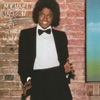

In [ ]:
def buscador_por_termino(termino,limite):
    #url API Searh endpoint
    url="https://itunes.apple.com/search"
    #Parametros necesarios (term=your+search+query(termino),media:"music",entity:"song",limit:"limite"
    params = {
        "term": termino,
        "media": "music",
        "entity": "song",
        "limit": limite
    }
    respuesta_1= requests.get(url,params=params,timeout=10)
    #En esta libreria se tiene que poner asi params para adjuntar nuestro diccionario a la url
    print("CODIGO DE ESTADO",respuesta_1.status_code)# ver si esta bien
    resultados=respuesta_1.json()["results"]#JSON de la lista con los datos
    print("="*50)
    print("\nDATOS JSON",resultados)
    for dato in resultados:
        print("\n")
        print("/"*50)
        titulo=dato.get('trackName')
        album=dato.get("collectionName")
        artista=dato.get('artistName')
        preview=dato.get('previewUrl')
        fecha=int(dato.get('releaseDate')[:4])
        genero= dato.get('primaryGenreName')
        #---------------CALCULO DURACION-----------------
        milisegundos= dato.get('trackTimeMillis')
        minutos = milisegundos// 60000 #De milisegundos a minutos
        segundos = (milisegundos % 60000) // 1000
        duracion =f"{minutos}:{segundos:02d}"#formato estandar de segundos
        #---------------DESCARGAR E IMPRIMIR IMAGEN-----------------
        imagen_url=dato.get('artworkUrl100')
        nombre_limpio = "".join(c for c in titulo if c.isalnum() or c in (" ", "_", "-")).rstrip()#como los nombres de las canciones pueden tener caracteres especiales estos se eliminan para no dañar el codigo
        archivo_local=f"{nombre_limpio}.jpg"
        descargar_imagen(imagen_url,archivo_local)
        print("="*50)
        print(f"TITULO:{titulo}\nALBUM:{album}\nARTISTA:{artista}\nGENERO:{genero}\nDURACION:{duracion}\nPREVIEW LINK:{preview}\nAÑO SALIDA:{fecha}")
        #Mostrar imagen
        display(Image(archivo_local))
        #--------------------------MOSTRAR AUDIO----------------------
        nombre_archivo=f"{nombre_limpio}Preview.m4a"
        info=requests.get(preview)
        with open(nombre_archivo,"wb") as archi:
          archi.write(info.content)
        display(Audio(nombre_archivo))
conn.commit()
buscador_por_termino("of the wall",1)

In [ ]:
# Conectar a la base de datos (o crear una de prueba)
conexion = sqlite3.connect('mi_base.db')

# Leer la tabla completa y guardarla en un DataFrame
df = pd.read_sql_query("SELECT * FROM nombre_de_tabla", conexion)

# Imprimir la tabla en Colab
print(df)

# Cerrar la conexión
conexion.close()

In [ ]:
#url API Searh endpoint
url="https://itunes.apple.com/search"
#Parametros necesarios (term=your+search+query )
#url API lookup endpoint para sacar la meta data
url_search_point="https://itunes.apple.com/lookup"
#
for dato in resultados:
    titulo=dato.get()

NameError: name 'resultados' is not defined